# python for stock trading


##### this ducument explains how to import stock's data from YAHOO, choose the best market to invest in, calculate you portfolio, and other intersting things.

In [60]:
import yfinance
import mplfinance as mpf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000

sns.set()

# downloading Data From YAHOO!

In [61]:
stocknames = ['AAPL', 'MSFT', 'TSLA', 'GC=F', 'SPY']
startdate = '2025-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [62]:
for stock in stocknames:
    df = yfinance.download(stock, start=startdate, end=enddate, interval=interval, auto_adjust=False, actions=False)
    df.reset_index(inplace=True)
    df.to_csv('{}.csv'.format(stock), index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [63]:
def appnding(cols = [], startdate='', enddate=''):
    global df
    dates = pd.date_range(start=startdate, end=enddate)
    df = pd.DataFrame(index=dates)
    
    for stock in stocknames:
        df_symbols = pd.read_csv('{}.csv'.format(stock), index_col='Date', parse_dates=True, usecols=cols, na_values=['NAN'])
        df_symbols = df_symbols.rename(columns={'Adj Close': stock})
        df = df.join(df_symbols)
    
    df = df.dropna()
    return df

In [64]:
appnding(['Date', 'Adj Close'], startdate, enddate)
df.index.names = ['Date']
df = df.rename(columns={'GC=F':'gold', 'AAPL' : 'aapl', 'MSFT' : 'msft', 'TSLA' : 'tsla', 'SPY':'spy'})
df.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,242.52516174316406,414.568603515625,379.2799987792969,2658.89990234375,576.2802734375
2025-01-03,242.03781127929688,419.29290771484375,410.44000244140625,2645.0,583.4857788085938
2025-01-06,243.66891479492188,423.7497863769531,411.04998779296875,2638.39990234375,586.8471069335938
2025-01-07,240.89405822753906,418.322265625,394.3599853515625,2656.699951171875,580.2133178710938
2025-01-08,241.38140869140625,420.49127197265625,394.94000244140625,2664.5,581.0609741210938


## GLOBAL STATISTICS

In [65]:
df = df.astype(float)
df_desc = df.describe().T
df_desc = df_desc[['count', 'mean', 'std', '50%', 'max']]
df_desc

,count,mean,std,50%,max
aapl,336.00,239.43,26.98,241.71,287.51
msft,336.00,449.49,51.41,455.12,539.83
tsla,336.00,368.29,64.86,378.42,489.88
gold,336.00,"3,800.37",738.61,"3,603.20","5,318.40"
spy,336.00,632.09,52.03,641.49,733.83


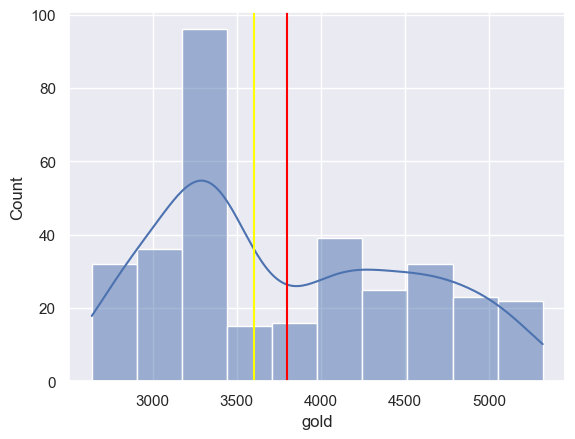

In [66]:
sns.histplot(data=df, x='gold', kde=True)
plt.axvline(df.gold.mean(), color="red")
plt.axvline(df.gold.median(), color="yellow")

In [67]:
px.line(data_frame=df, title='tickers adj. close price')

### normalizing

In [68]:
norm = df / df.iloc[0,:]
fig = px.line(norm)
fig.update_layout(title='stack movement observation by normalizing adj close prices , (daily cumulative return)',
                   xaxis_title='Date', 
                   yaxis_title='Normalized price')
fig.show()

<Axes: xlabel='tsla', ylabel='Count'>

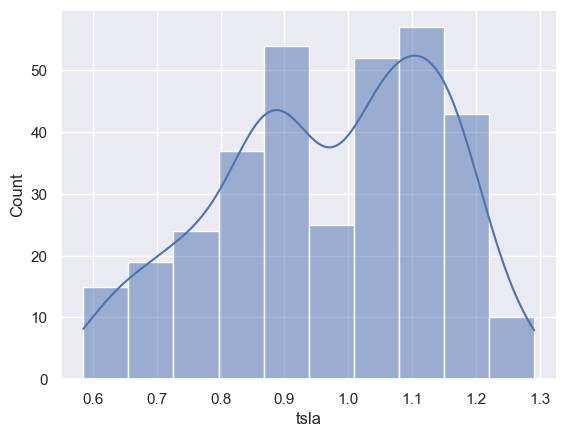

In [69]:
sns.histplot(data=norm, x=norm['tsla'], kde=True)

### Rolling Statistics

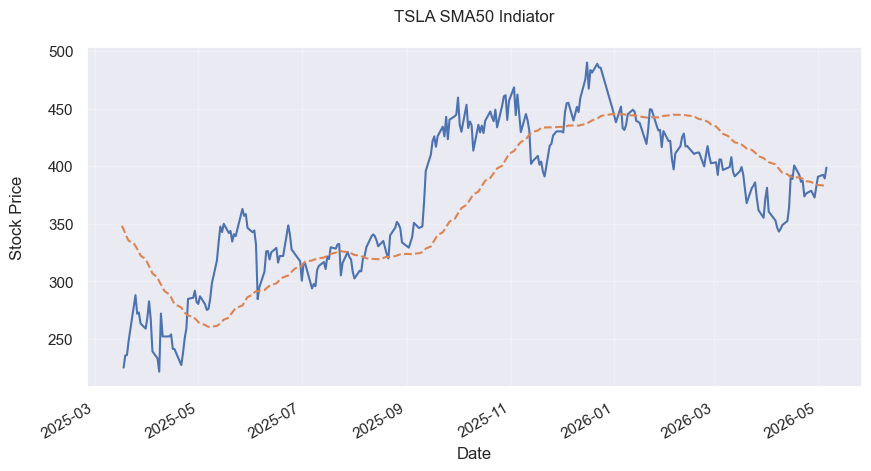

In [70]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(10,5))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('TSLA SMA50 Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
plt.grid(alpha=0.25)

### Bollinger Bands

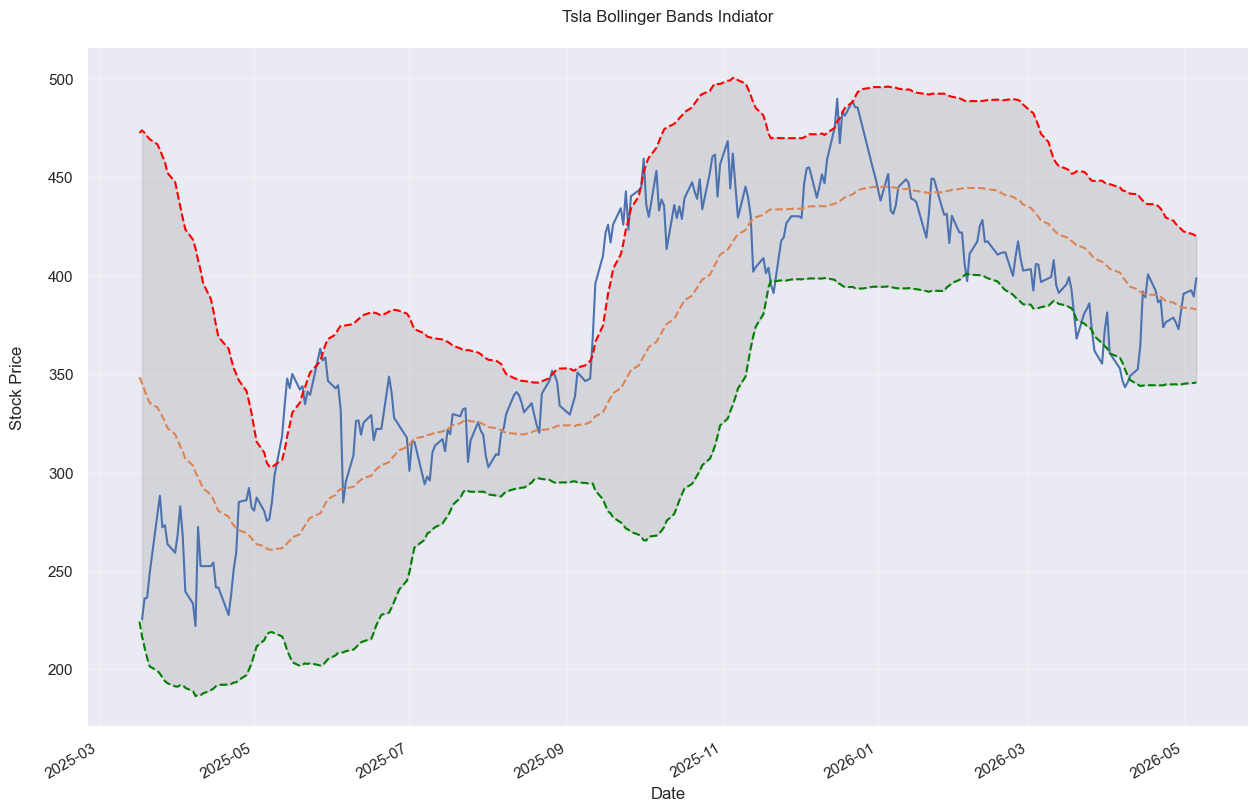

In [71]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(15,10))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('Tsla Bollinger Bands Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
upper_band = rollingmean + rollingstd
lower_band = rollingmean - rollingstd
upper_band.plot(ax=ax, linestyle='--', label='Upper Band (+2 STD)', color='red')
lower_band.plot(ax=ax, linestyle='--', label='Lower Band (-2 STD)', color='green')
ax.fill_between(df.index[50:], upper_band.iloc[50:], lower_band.iloc[50:], alpha=0.2, color='gray')
plt.grid(alpha=0.25)

### - Matrics

-daily Returns
-commuulative Returns
-sharpe Ratio

In [72]:
daily_returns = df.pct_change()
daily_returns.iloc[0,:] = 0
daily_returns.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,0.00,0.00,0.00,0.00,0.00
2025-01-03,-0.00,0.01,0.08,-0.01,0.01
2025-01-06,0.01,0.01,0.00,-0.00,0.01
2025-01-07,-0.01,-0.01,-0.04,0.01,-0.01
2025-01-08,0.00,0.01,0.00,0.00,0.00


In [73]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,336.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,336.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,336.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,336.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,336.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


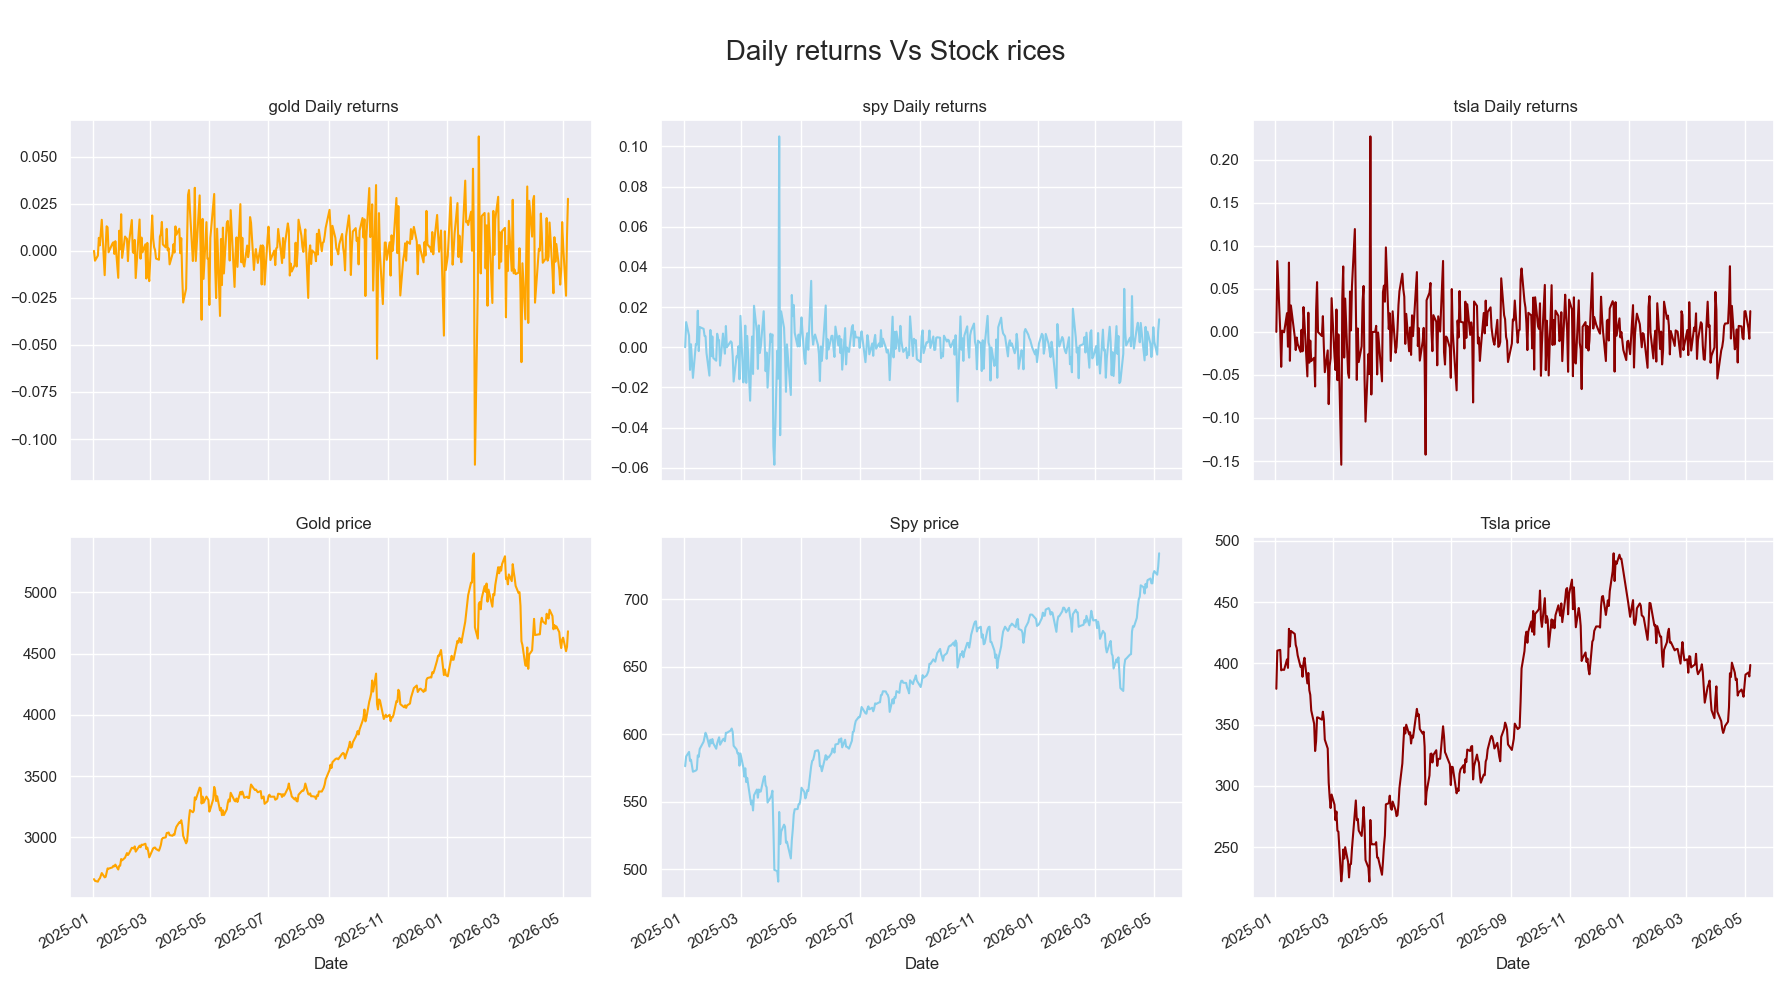

In [93]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

daily_returns.gold.plot(ax=ax[0][0], color='orange')
ax[0][0].set_title('\n gold Daily returns')

daily_returns.spy.plot(ax=ax[0][1], color='skyblue')
ax[0][1].set_title('\n spy Daily returns')

daily_returns.tsla.plot(ax=ax[0][2], color='darkred')
ax[0][2].set_title('\n tsla Daily returns')

df.gold.plot(kind='line', ax=ax[1][0], color='orange')
ax[1][0].set_title('\n Gold price')

df.spy.plot(kind='line', ax=ax[1][1], color='skyblue')
ax[1][1].set_title('\n Spy price')

df.tsla.plot(kind='line', ax=ax[1][2], color='darkred')
ax[1][2].set_title('\n Tsla price')
fig.suptitle('\n Daily returns Vs Stock rices', fontsize=20)
plt.tight_layout()

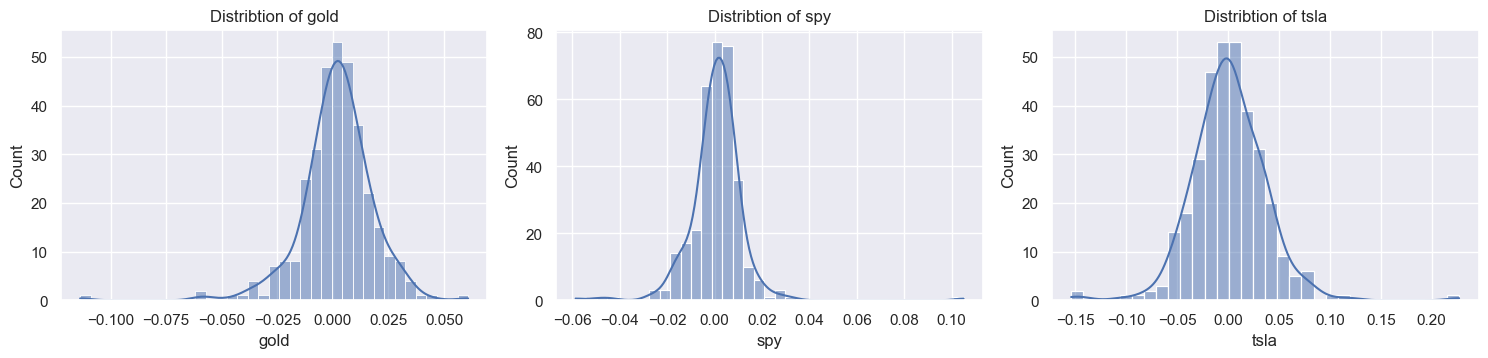

In [94]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['gold', 'spy', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True)
    plt.title("Distribtion of " + i)
    plt.tight_layout()




### cumulative returns ratio: is the profit/lose ratio of the stock on practicular period 